In [1]:
%matplotlib inline

import datetime, time
import numpy as np
import xesmf as xe
import xarray as xr
import netCDF4 as nc
import cmocean as cm
import matplotlib.ticker
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

import warnings
warnings.filterwarnings('ignore')

In [2]:
ctrl = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_bc_x05/output000/ocean.stats.nc')
sm_HBBL = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_bc_x05_HBBL_x01/output000/ocean.stats.nc')
scalex4 = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_bc_x20/output000/ocean.stats.nc')
cdragx4 = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_bc_x05_cd_x04/output000/ocean.stats.nc')

In [33]:
bt = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_x05/output000/ocean.stats.nc')
bc = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_x02/output000/ocean.stats.nc')

In [34]:
en_bt = bt.En
en_bc = bc.En
print(np.nanmax(en_bt))
print(np.nanmax(en_bc))

3.6664567002277786e+17
6.68286551002197e+17


In [35]:
t_bt = bt.Time /21600000000000
t_bc = bc.Time /21600000000000
print(t_bt.values)
print(t_bc.values)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


In [3]:
en_ctrl = ctrl.En
en_hbbl = sm_HBBL.En
en_scx4 = scalex4.En
en_cdx4 = cdragx4.En

In [11]:
print(np.nanmax(en_ctrl))
print(np.nanmax(en_hbbl))
print(np.nanmax(en_scx4))
print(np.nanmax(en_cdx4))

2.625149825960941e+18
1.1766956538666554e+17
2.5542922661195484e+18
1.8293622309511933e+17


In [5]:
print(en_ctrl.shape)
print(en_hbbl.shape)
print(en_scx4.shape)
print(en_cdx4.shape)

(41,)
(5,)
(5,)
(5,)


In [9]:
t_ctrl = ctrl.Time /21600000000000
t_hbbl = sm_HBBL.Time /21600000000000
t_scx4 = scalex4.Time /21600000000000
t_cdx4 = cdragx4.Time/21600000000000

In [10]:
print(t_ctrl.values)
print(t_hbbl.values)
print(t_scx4.values)
print(t_cdx4.values)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]
[0 1 2 3 4]
[0 1 2 3 4]
[0 1 2 3 4]


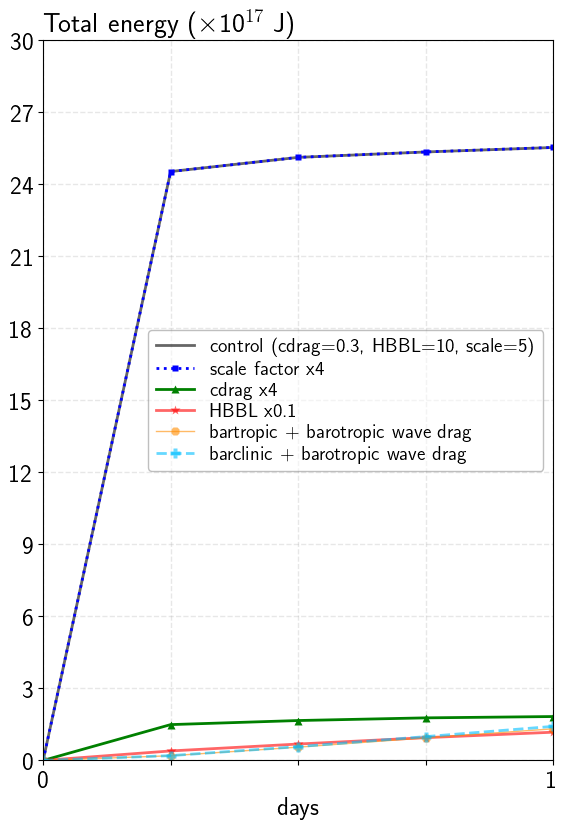

In [57]:
# Enable LaTeX text rendering
plt.rc('text', usetex=True)

fig = plt.figure(figsize=(6, 9))
axs = []

gridsubs = gridspec.GridSpec(1,1)
for gs in gridsubs:
    axs.append(plt.subplot(gs))

for I, ax in enumerate(axs):
    
    # ax.set_xlim(0,42)
    # ax.set_xticks(np.array([0,4,8,12,16,20,24,28,32,36,40]))
    # ax.set_xticklabels(['0','1','2','3','4','5','6','7','8','9','10'])
    ax.set_xlim(0,4)
    ax.set_xticks(np.array([0,1,2,3,4]))
    ax.set_xticklabels(['0','','','','1'])
    ax.set_xlabel('days',fontsize=18)
    ax.tick_params(labelsize=18)

    if I==0:
        ax.plot(t_ctrl,en_ctrl,'k',alpha=0.6,markersize=7,linewidth=2,label='control (cdrag=0.3, HBBL=10, scale=5)')
        ax.plot(t_scx4,en_scx4,'b:',marker='s',markersize=5,linewidth=2,markeredgecolor='none',
    markerfacecolor='b',label='scale factor x4')
        ax.plot(t_cdx4,en_cdx4,'g',marker='^',markersize=6,linewidth=2,markeredgecolor='none',
    markerfacecolor='g',label='cdrag x4')
        ax.plot(t_hbbl,en_hbbl,'r',marker='*',alpha=0.6,markersize=7,linewidth=2,markeredgecolor='none',
    markerfacecolor='r',label='HBBL x0.1')
        ax.plot(t_bt,en_bt,'darkorange',marker='8',alpha=0.6,markersize=7,linewidth=1,markeredgecolor='none',
    markerfacecolor='darkorange',label='bartropic + barotropic wave drag')
        ax.plot(t_bc,en_bc,'deepskyblue',linestyle='--',marker='P',alpha=0.6,markersize=7,linewidth=2,markeredgecolor='none',
    markerfacecolor='deepskyblue',label='barclinic + barotropic wave drag')
        
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
        ax.set_ylim(0,3e+18)
        ax.set_yticks(np.arange(0,3e+18+3e+17,3e+17))
        ax.set_yticklabels(['0','3','6','9','12','15','18','21','24','27','30'])
        leg = ax.legend(loc=0,handlelength=2,fontsize=14,labelspacing=0.2,frameon=True)
        leg.get_frame().set_facecolor('white')  # background color
        leg.get_frame().set_alpha(0.5) 
        leg.get_frame().set_edgecolor('gray')
        ax.set_title(r'Total energy ($\times$10$^{17}$ J)',fontsize=20,loc='left')
        ax.set_position([0.1,0.1,0.85,0.8])

# plt.savefig('dir/*.png', dpi=600, bbox_inches='tight')